<a href="https://colab.research.google.com/github/quentin02noel/2025_Intro_Python/blob/main/notebook/FEEDBACK_QUENTIN_NOEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# (Exercise) Ocean Floats Data Analysis

**Learning Objectives**

*    Creating new arrays using `linspace` and `arange`
*    Computing basic formulas with `numpy` arrays
*    Loading data from `.npy` files
*    Performing reductions (e.g. `mean`, `std` on `numpy` arrays)
*    Making 1D line plots
*    Making scatterplots
*    Annotating plots with titles and axes

In this problem, we use real data from ocean profiling floats. [ARGO](http://www.argo.ucsd.edu/) floats are autonomous robotic instruments that collect Temperature, Salinity, and Pressure data from the ocean. [ARGO](http://www.argo.ucsd.edu/) floats collect one “profile” (a set of messurements at different depths or “levels”).

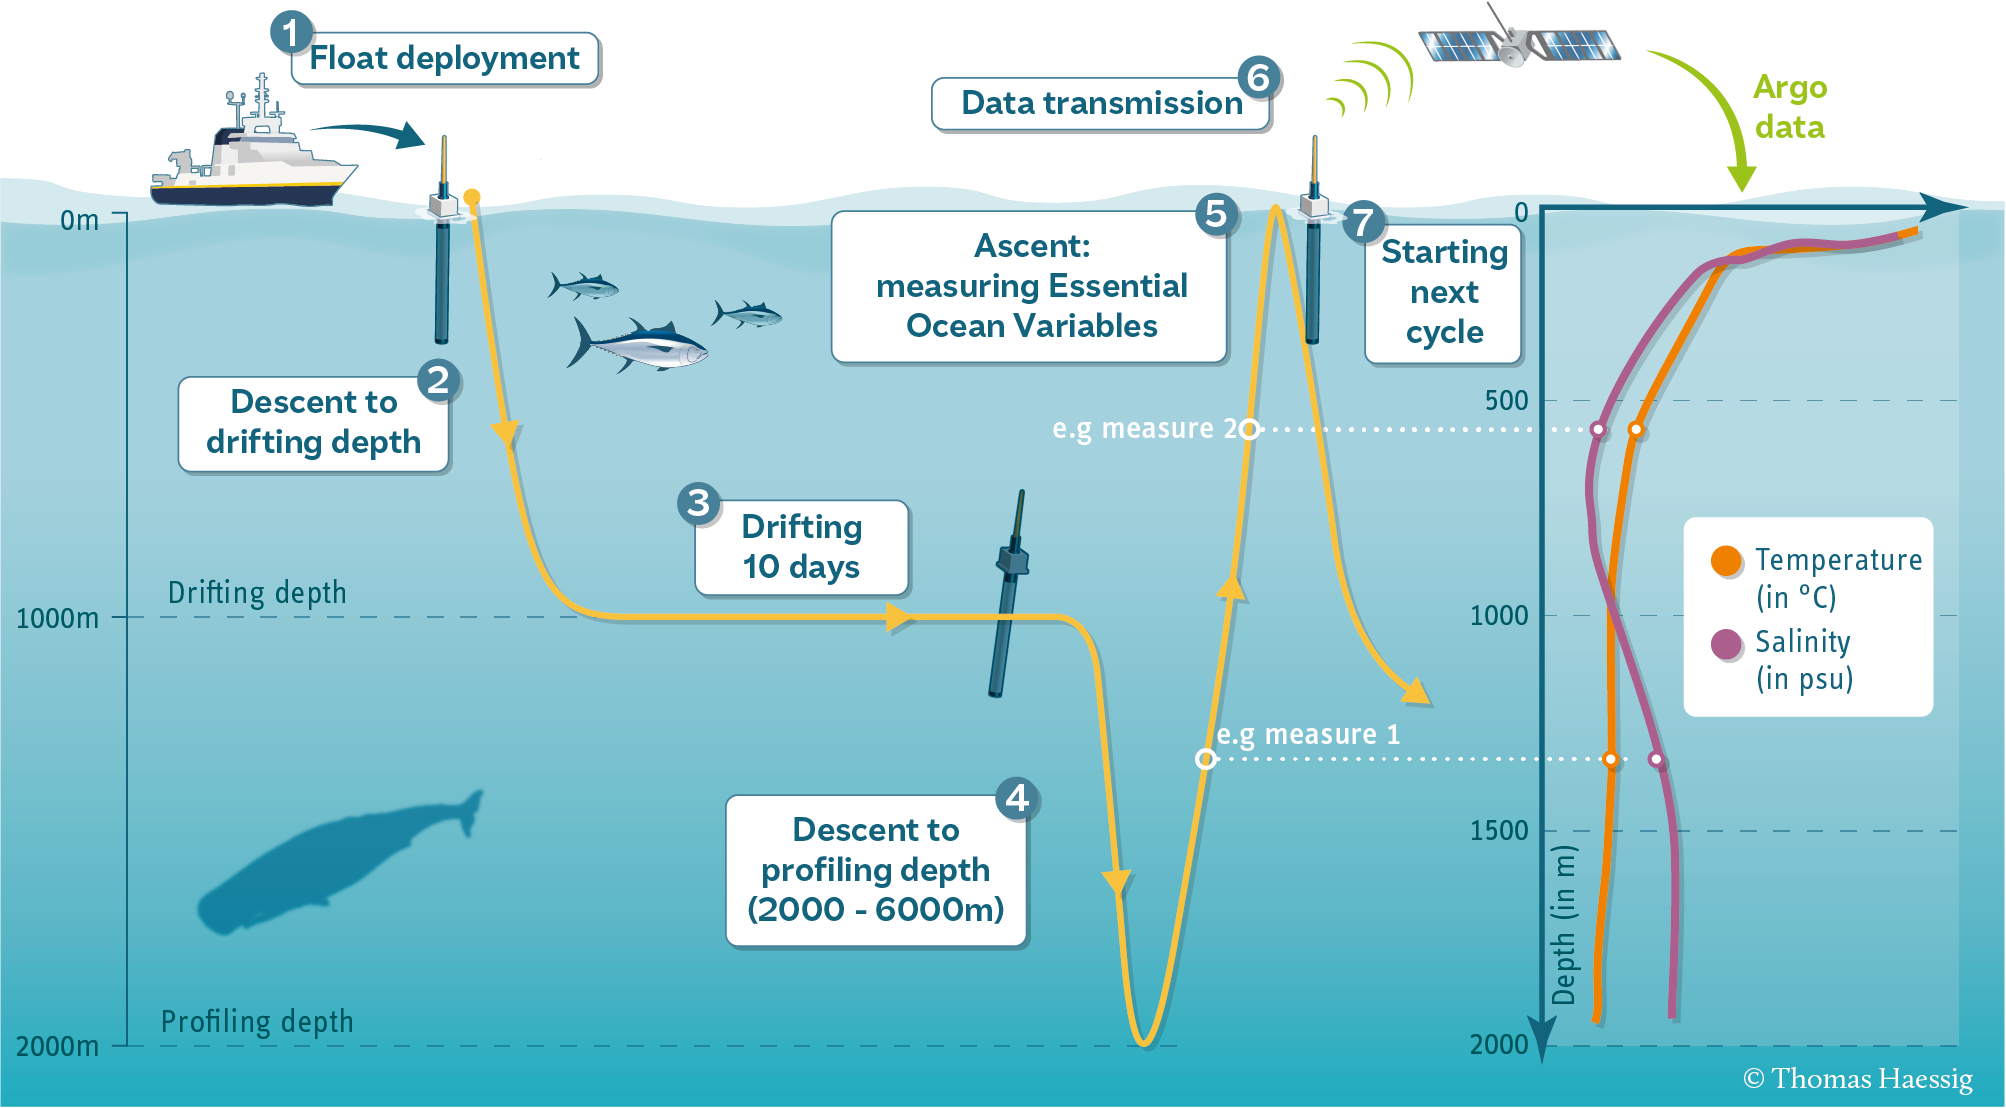


Each profile has a single latitude, longitude, and date associated with it, in addition to many different levels.

Let’s start by using [pooch](https://www.fatiando.org/pooch/latest/) to download the data files we need for this exercise. The following code will give you a list of `.npy` files that you can open in the next step.

In [1]:
import pooch

url = "https://unils-my.sharepoint.com/:u:/g/personal/tom_beucler_unil_ch/EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ?download=1"
files = pooch.retrieve(url, processor=pooch.Unzip(), known_hash='2a703c720302c682f1662181d329c9f22f9f10e1539dc2d6082160a469165009')
files

# Very important!! This code is wrong for the simple reason that it imports the files randomly,
# which means that you won't have the same order of files each time you run this section.
# That is the origin of all my problems for this exercise series. For instance, on Wednesday 8 October, I had this order:
# lon = np.load(files[0])
#S = np.load(files[1])
#P = np.load(files[2])
#date = np.load(files[3])
#levels = np.load(files[4])
#T = np.load(files[5])
#lat = np.load(files[6])

# However, on Saturday 11 October, I had this order:

#date = np.load(files[0])
#lat = np.load(files[1])
#T = np.load(files[2])
#S = np.load(files[3])
# lon = np.load(files[4])
#levels = np.load(files[5])
#P = np.load(files[6])


# This means that you will not have the same order of file imports. Be careful when you run the code!!

#LOOK AT THE TEXT FEEDBACK PARAGRAPH TO UNDERSTAND ALL THE STEPS OF MY UNDERSTANDING

['/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/date.npy',
 '/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/lat.npy',
 '/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/T.npy',
 '/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/S.npy',
 '/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/lon.npy',
 '/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/levels.npy',
 '/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/P.npy']

In [2]:
import numpy as np

**Q1) Load each data file as a `numpy` array.**

You can use whatever names you want for your arrays, but we recommend:

`T`: temperature

`S`: salinity

`P`: pressure

`date`: date

`lat`: latitude

`lon`: longitude

`level`: depth level

Hint 1: Look at the file name (the items in `files`) to know which files corresponds to which variable.

Hint 2: Check out the documentation for [`np.load`](https://numpy.org/doc/stable/reference/generated/numpy.load.html).

Display the names of the items in files here

In [3]:
#SNIPPET ii HERE
#I decided to import the files with the name of them to be able to have always the files in the correct order.
#To create this, i had to make a loop and introducing the keyword of the file in np.load to have the correct order !

for f in files:
    print(f)

def find_file(files, keyword):
  return [f for f in files if keyword in f][0]

S = np.load(find_file(files, 'S.npy'))
T = np.load(find_file(files, 'T.npy'))
P = np.load(find_file(files, 'P.npy'))
date = np.load(find_file(files, 'date.npy'))
lat = np.load(find_file(files, 'lat.npy'))
lon = np.load(find_file(files, 'lon.npy'))
levels = np.load(find_file(files, 'levels.npy'))

/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/date.npy
/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/lat.npy
/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/T.npy
/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/S.npy
/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/lon.npy
/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/levels.npy
/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/P.npy


#Text feedback

At the beginning, I thought that I had imported the files in the wrong order, which gave me incorrect variable values. Because of that, the arrays didn’t have the expected lengths, and the level_arange array was always incorrect.

Initially, I imported the files in this order:

T = np.load(files[0])

S = np.load(files[1])

P = np.load(files[2])

date = np.load(files[3])

lat = np.load(files[4])

lon = np.load(files[5])

level = np.load(files[6])

When I checked the size of level_arange with np.arange, it didn’t match, and I assumed there was a problem with the shape of the arrays. Later, when I tried to compute the Conservative Temperature using CT_from_T, it failed again because the arrays didn’t have the same shapes.

So, firstly, I tried to create a code that could artificially modify the shapes of my variables in order to obtain the desired array for running the CT_from_T formula:

Extend S and T in two dimensions so they match P

S_2D = np.tile(S[np.newaxis, :], (78, 1))  -> (78, 75)

T_2D = np.tile(T[:, np.newaxis], (1, 75))  --> (78, 75)
print(P.shape)

P_2D = P.reshape((1, len(P)))

print(S_2D.shape, T_2D.shape, P.shape)

print(S_2D)



Thanks to the TA, we found that the problem
was coming from my files that were not correctly imported in the right order. However, at this monment we could not know that the real origin of the problem was coming from the file importation. When we saw with them, the code was perfectly running. So we conclude that it was only due to the fact that I simply imported the files in the wrong order.

However, when I ran the same code again another day, the shapes were incorrect once more. I decided to verify the imported files again, and I noticed that they were not in the same order as before. That’s when I understood that the issue came from the pooch.retrieve() function, which imports the files in a random order.

Now, as you can see, the files are always imported in the correct order. This is because I changed the way the code loads them, by sorting or naming them explicitly. Maybe it would be better to change the file importation method for next year’s students, because this issue can cause a lot of confusion. Students may end up debugging a problem that is not caused by their code, but by the way the files are imported at the beginning of the exercise.


In [4]:
#SNIPPET i HERE
# As explained before, this code here has become obsolete:
for file in files:  # This loop allows checking the lines contained in each file
    print(file)
# lon = np.load(files[0])
# S = np.load(files[1])
# P = np.load(files[2])
# date = np.load(files[3])
# levels = np.load(files[4])
# T = np.load(files[5])
# lat = np.load(files[6])
print(S.shape)
print(P.shape)
print(T.shape)

/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/date.npy
/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/lat.npy
/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/T.npy
/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/S.npy
/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/lon.npy
/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/levels.npy
/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/P.npy
(78, 75)
(78, 75)
(78, 75)


Then, load the files as `numpy` arrays, for instance using list comprehension

In [5]:
#S,level,T,lat,lon,date,P = [np.load(files[i]) for i in range(7)] I am not using this line because it is not necessary for the rest of the exercise.

**Q2) Recreate the `level` array using `np.arange` and `np.linspace`**

Hints:

*   The documentation for `np.arange` is [at this link](https://numpy.org/devdocs/reference/generated/numpy.arange.html)
*   The documentation for `np.linspace` is [at this link](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html)
*   The documentation for `np.testing.assert_equal` is [at this link](https://numpy.org/doc/stable/reference/generated/numpy.testing.assert_equal.html)

Display the `level` array

In [6]:
print(levels)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77]


Recreate the `level` array using `np.arange` and call it `level_arange`

In [7]:
level_arange = np.arange(levels[0], levels[-1]+1, step=1) #demander

Check that `level` and `level_arange` are equal using `np.testing.assert_equal`

In [8]:
np.testing.assert_equal(levels,level_arange)

Recreate the `level` array using `np.linspace` and call it `level_linspace`

In [9]:
level_linspace = np.linspace(start=levels[0], stop=levels[-1], num=len(levels))
print(level_linspace)

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53.
 54. 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68. 69. 70. 71.
 72. 73. 74. 75. 76. 77.]


Check that `level` and `level_linspace` are equal using `np.testing.assert_equal`

In [10]:
np.testing.assert_equal(levels,level_linspace)

**Q3) Examine the shapes of `T`, `S` and `P` compared to `lon`, `lat`, `date` and `level`. How do you think they are related?**

Hint: Check out the [NDArrays subsection](#NDArrays)

Display the shapes of all loaded variables

In [11]:
print(T.shape)
print(S.shape)
print(P.shape)

(78, 75)
(78, 75)
(78, 75)


In [12]:
print(lon.shape)
print(lat.shape)
print(date.shape)
print(levels.shape)

(75,)
(75,)
(75,)
(78,)


Based on the shapes, which dimensions do you think are shared among the arrays?

**Q4) Based on the formula below, calculate the seawater density `relative_density`, relative to pure water, as a function of the temperature, the salinity, and the pressure.**

`relative_density`$ = ρ −ρ_{Pure\ Water} = a \times S +b \times \Theta + c \times \Theta^{2}$

where:

*    The densities $\rho$ and $ρ_{Pure\ Water}$ are in units $kg/m^{3}$.
*    The constants $a$, $b$, and $c$ are provided below.
*    The function to calculate the conservative temperature $\Theta$ (in units Celcius) from temperature, salinity, and pressure is provided below.
*    The temperature $T$ is in units Celcius.
*    The salinity $S$ is in units $g/kg$.
*    The pressure $p$ is in units $dbar$.

Hint: The loaded `numpy` arrays `temperature`, `salinity`, and `pressure` already have the right units and no conversion is needed.

Sources:

1) [*Roquet, Fabien, et al. "Defining a simplified yet “realistic” equation of state for seawater." Journal of Physical Oceanography 45.10 (2015): 2564-2579.*](https://journals.ametsoc.org/view/journals/phoc/45/10/jpo-d-15-0080.1.xml)

2) [*The Gibbs SeaWater (GSW)
Oceanographic Toolbox of TEOS-10*](https://www.teos-10.org/pubs/gsw/html/gsw_front_page.html). [(License)](https://www.teos-10.org/pubs/gsw/html/gsw_licence.html)

Below are the constants a, b, and c:

In [13]:
a = 7.718e-1
b = -8.44e-2
c = -4.561e-3

Let's import the library [`gsw`](https://teos-10.github.io/GSW-Python/) that contains the function `CS_from_t`to calculate the conservative temperature $\Theta$ from temperature, salinity, and pressure.

In [14]:
!pip install gsw
from gsw import CT_from_t

Now it's all up to you. Here's the equation to avoid having to scroll back up:

`relative_density`$ = ρ −ρ_{Pure\ Water} = a \times S +b \times \Theta + c \times \Theta^{2}$

Calculate the conservative temperature

Hint: use [CT_from_t](https://www.teos-10.org/pubs/gsw/html/gsw_CT_from_t.html)

In [15]:
import numpy as np
from gsw import CT_from_t

print(P.shape)
print(T)

(78, 75)
[[18.97400093 18.43700027 19.09900093 ... 19.11300087 21.82299995
  20.13100052]
 [18.74099922 18.39999962 19.08200073 ... 18.47200012 19.45999908
  20.125     ]
 [18.37000084 18.37400055 19.06500053 ... 18.22999954 19.26199913
  20.07699966]
 ...
 [ 3.79299998  3.81399989  3.80200005 ...  3.80699992  3.81100011
   3.8599999 ]
 [ 3.76399994  3.77800012  3.75699997 ...  3.75399995  3.74600005
   3.80599999]
 [ 3.74399996  3.74600005  3.7249999  ...         nan  3.71399999
          nan]]


In [16]:
CT = CT_from_t(S,T,P)

a = 7.718e-1
b = -8.44e-2
c = -4.561e-3
print(CT)


[[18.95038389 18.41702486 19.07746816 ... 19.0838613  21.79604023
  20.10691816]
 [18.7167823  18.37902205 19.05973411 ... 18.44249588 19.43744461
  20.10022206]
 [18.34343364 18.3522886  19.04195407 ... 18.20006431 19.23615405
  20.05124564]
 ...
 [ 3.6359899   3.65662809  3.64478998 ...  3.64962307  3.65341962
   3.70166094]
 [ 3.60272526  3.61639726  3.59575608 ...  3.59259633  3.58470724
   3.6437391 ]
 [ 3.57826951  3.58028581  3.55956863 ...         nan  3.54839488
          nan]]


Calculate the `relative density` using the equation above

In [17]:
relative_density = a * S + b * CT + c * CT**2

print(relative_density)

[[24.26878778 24.30901623 24.18510597 ... 24.37483439 23.60704513
  23.98828331]
 [24.32477667 24.32400413 24.19045883 ... 24.53101768 24.09992029
  23.98930505]
 [24.45644758 24.33382758 24.19427794 ... 24.58041622 24.21339484
  24.000865  ]
 ...
 [26.58088425 26.58466521 26.58605858 ... 26.59390729 26.5980916
  26.59702996]
 [26.58479005 26.58939524 26.59027359 ... 26.59905835 26.60307089
  26.60154496]
 [26.58919785 26.59362837 26.59605156 ...         nan 26.60731704
          nan]]


**Q4) Make a plot for each column of data in `T`, `S`, `P`, and
`relative_density` (four plots)**

For this question, we have to use the [Pyplot interface](https://matplotlib.org/stable/tutorials/introductory/pyplot.html) of the [Matplotlib library](https://matplotlib.org/) for visualization even if we have not covered it extensively in class yet. But fear not as we provide easy-to-follow instructions below. 😊

The first step is to import Pyplot. Simply execute the code below.

In [18]:
import matplotlib.pyplot as plt

Then, we will plot variables as a function of the ocean depth, `level`. Simply read the documentation [at this link](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) to infer the correct syntax. Label your axes using `plt.xlabel` and `plt.ylabel`, and add a title using `plt.title`.

Hint: The vertical scale should use the `level` data to be consistent with oceanographic conventions.

Hint 2: Each plot should have a line for each column of data. It will look messy, like the plot below:

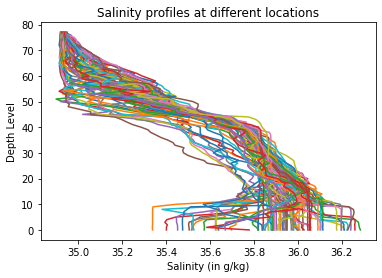

Text(0.5, 1.0, 'Salintiy profiles at different locations')

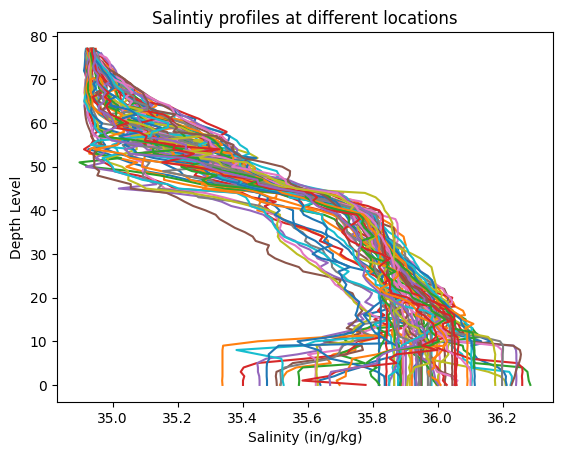

In [19]:
plt.plot(S,levels); # The semi-colon prevents printing the line objects
plt.xlabel('Salinity (in/g/kg)') # Takes a string as argument
plt.ylabel('Depth Level')
plt.title('Salintiy profiles at different locations')

Make more plots below:

Text(0.5, 1.0, 'Temperature for first float')

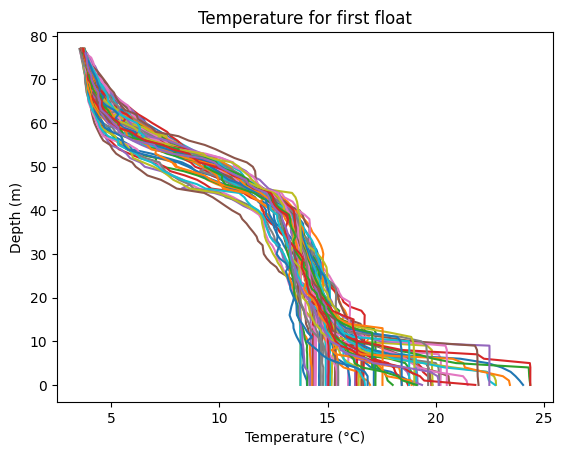

In [20]:
plt.plot(T, levels)      # première colonne
plt.xlabel('Temperature (°C)')
plt.ylabel('Depth (m)')
plt.title('Temperature for first float')

Text(0.5, 1.0, 'Depth as a funciton of pressure')

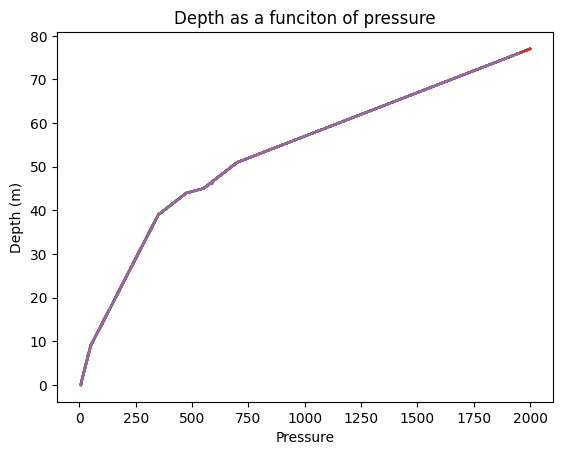

In [21]:
plt.plot(P, levels)      # première colonne
plt.xlabel('Pressure')
plt.ylabel('Depth (m)')
plt.title('Depth as a funciton of pressure')

Text(0.5, 1.0, 'Depth as a function of relative density')

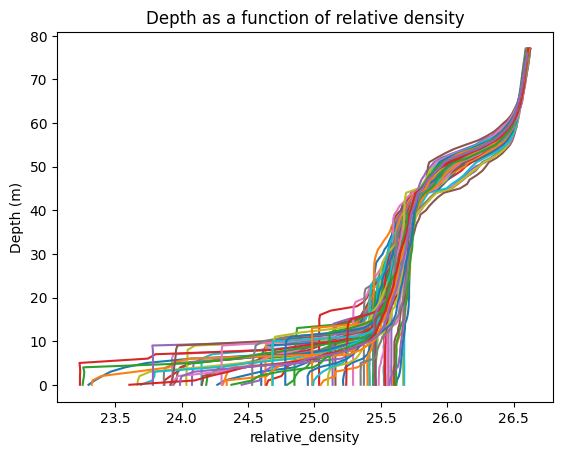

In [22]:
plt.plot(relative_density, levels)      # première colonne
plt.xlabel('relative_density')
plt.ylabel('Depth (m)')
plt.title('Depth as a function of relative density')

**Q5) Compute the mean and standard deviation of each of `T`, `S`, `P`, and `seawater_density` at each depth in `level`.**

Hint: You may want to read the documentation at [this link](https://numpy.org/doc/stable/reference/generated/numpy.mean.html) and [this link](https://numpy.org/doc/stable/reference/generated/numpy.std.html).

Hint 2: You can check that you took the mean and standard deviations along the correct axes by checking the `shape` of your results.

Compute the means...

In [23]:
tmean = np.nanmean(T, axis=1)
smean = np.nanmean(S, axis=1)
pmean = np.nanmean(P, axis=1)
rdmean = np.nanmean(relative_density, axis=1)

In [24]:
print("tmean:", tmean.shape)
print("smean:", smean.shape)
print("pmean:", pmean.shape)
print("rdmean:", rdmean.shape)

tmean: (78,)
smean: (78,)
pmean: (78,)
rdmean: (78,)


... and the standard deviations.

In [25]:
Tstd = np.nanstd(T,axis=1)
print(Tstd)

[2.92500898 2.86405591 2.83324563 2.75112353 2.60248422 2.42649165
 2.20220589 1.99752543 1.79105862 1.74132795 1.26608465 1.07857596
 0.89761236 0.79748479 0.68525328 0.6394096  0.61835635 0.59387877
 0.56010736 0.55009107 0.53183794 0.52634089 0.52668259 0.51009182
 0.49376838 0.48980214 0.48551874 0.48516171 0.49244536 0.50557331
 0.50881718 0.50482633 0.50093284 0.51411271 0.50962002 0.51399949
 0.52544584 0.53182873 0.5466501  0.55060902 0.56066216 0.57937588
 0.5989958  0.63392862 0.70640057 0.85775269 0.84204226 0.90031954
 0.94661515 0.9902255  1.01786435 1.01690775 1.01944275 0.97987767
 0.94359878 0.88207755 0.82934499 0.7859263  0.71755907 0.68351183
 0.64382025 0.58990336 0.55077313 0.50187175 0.45673872 0.4085324
 0.36748504 0.33272584 0.2996815  0.25570195 0.21802589 0.17365755
 0.14408683 0.11509768 0.09214697 0.08062746 0.06846311 0.06550644]


In [26]:
Sstd= np.nanstd(S, axis=1)
print(Sstd)

[0.21775056 0.22181831 0.21880847 0.21661592 0.20842504 0.19440186
 0.18227015 0.17652957 0.16993855 0.16035545 0.13927144 0.11711354
 0.10460508 0.09743633 0.0927479  0.08493034 0.08485861 0.08050515
 0.07776356 0.07558179 0.07282218 0.07121873 0.07207327 0.07187564
 0.07096565 0.07295663 0.07539408 0.07641816 0.07825997 0.08340698
 0.08535978 0.08535099 0.08681939 0.09210511 0.0933961  0.09597163
 0.09981623 0.10239233 0.10576448 0.10694631 0.10584218 0.10579345
 0.10557016 0.10840863 0.11562906 0.12566351 0.11644936 0.12211051
 0.12341583 0.12609271 0.12781264 0.12486204 0.12508305 0.12873388
 0.1271157  0.12208639 0.11848103 0.11478619 0.10416219 0.1009587
 0.09565639 0.08961304 0.0856126  0.07880695 0.07300245 0.06582414
 0.05933736 0.05371506 0.04872476 0.04207644 0.0362379  0.02930639
 0.02457704 0.01954141 0.01546896 0.01236431 0.01010649 0.00788405]


In [27]:
Pstd = np.nanstd(P, axis = 1)
print(Pstd)

[0.8534625  0.37341592 0.38353723 0.36770566 0.55606262 0.50754902
 0.42492636 0.6317751  0.48483957 0.65125039 0.40346418 0.4673176
 0.56304492 0.47487075 0.44050136 0.51091269 0.26877946 0.37268007
 0.2706112  0.29950074 0.42956802 0.33438258 0.31173771 0.37437015
 0.34679885 0.44303045 0.63734733 0.51525968 0.70184377 0.5223867
 0.51517567 0.61400897 0.51982487 0.49389381 0.54115544 0.40921099
 0.3580466  0.30919436 0.34628242 0.30929789 0.30294174 0.3579114
 0.36852196 0.49155671 0.55271425 0.4291849  1.5931604  0.28791041
 0.50431884 0.3960767  0.58088542 0.5878231  0.46728604 0.38447582
 0.4927975  0.4390579  0.31427165 0.28784061 0.40978017 0.39367447
 0.26551312 0.36947741 0.61174401 0.34210648 0.43511937 0.33283111
 0.52793873 0.55593409 0.35726761 0.27060041 0.35534457 0.56095549
 0.42508157 0.40772683 0.30768563 0.32852691 0.32928914 1.3524533 ]


In [28]:
relative_density_std = np.nanstd(relative_density, axis=1)
print(relative_density_std)

[0.72628301 0.71056568 0.70081643 0.67881162 0.64138477 0.5940689
 0.53119921 0.47274702 0.41060919 0.3944036  0.26406948 0.21696375
 0.17136278 0.15224668 0.12259564 0.11235218 0.10390261 0.09645264
 0.08575266 0.08238438 0.07845066 0.07664579 0.07471934 0.07017307
 0.06593684 0.06311117 0.06108226 0.05923067 0.05819081 0.05585184
 0.05351971 0.05178967 0.04918457 0.04712294 0.04451595 0.04251347
 0.04121078 0.03973457 0.03914086 0.03753483 0.03750514 0.03940821
 0.04072732 0.04245762 0.04731466 0.06110755 0.06560189 0.06954326
 0.07525136 0.08012412 0.08297409 0.08501657 0.0849015  0.07918053
 0.06847191 0.05889347 0.04711212 0.03604723 0.0282499  0.02338445
 0.01821967 0.01424514 0.01090861 0.00923819 0.00845313 0.00774326
 0.00694736 0.00663108 0.00649737 0.00681396 0.00683985 0.0069283
 0.00730848 0.00736786 0.00743527 0.00728612 0.00736686 0.00821908]


Check that they have the same shape as your vertical level `lev` coordinate:

In [29]:
np.testing.assert_equal(tmean.shape, levels.shape)
np.testing.assert_equal(smean.shape, levels.shape)
np.testing.assert_equal(pmean.shape, levels.shape)
np.testing.assert_equal(rdmean.shape, levels.shape)

**Q6) Now make similar plots, but show only the mean `T`, `S`, `P`, and `seawater_density` at each depth. Show error bars on each plot using the standard deviations.**

Hint: If you are feeling adventurous, you can directly use the [`plt.errorbar`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.errorbar.html) function.

Hint 2: You should get plots similar to the one below

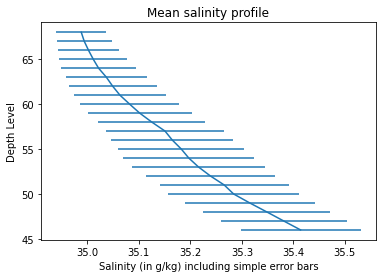

Text(0.5, 1.0, 'Mean Salinity profile')

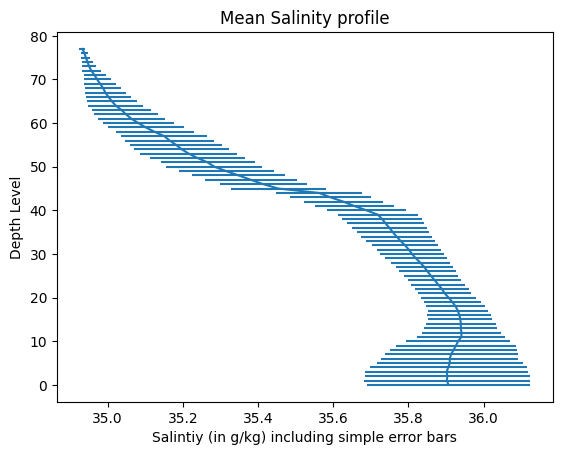

In [30]:
plt.errorbar(smean,levels,xerr=Sstd)
plt.xlabel('Salintiy (in g/kg) including simple error bars')
plt.ylabel('Depth Level')
plt.title('Mean Salinity profile')

Three more plots and we'll be all set! 🙂

Text(0.5, 1.0, 'Depth as a function of temperature')

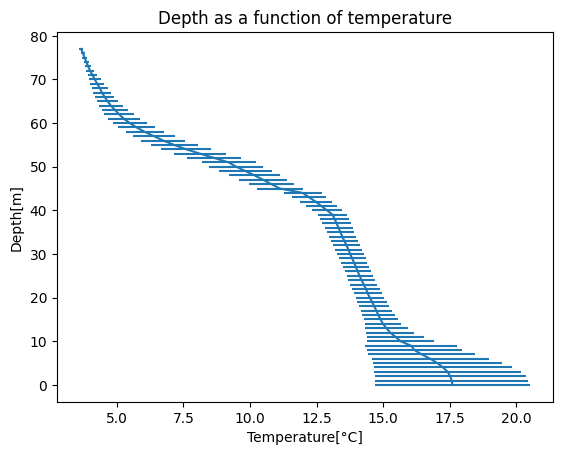

In [31]:
plt.errorbar(tmean, levels, xerr=Tstd)
plt.xlabel('Temperature[°C]')
plt.ylabel('Depth[m]')
plt.title('Depth as a function of temperature')

Text(0.5, 1.0, 'Depth as a function of pressure')

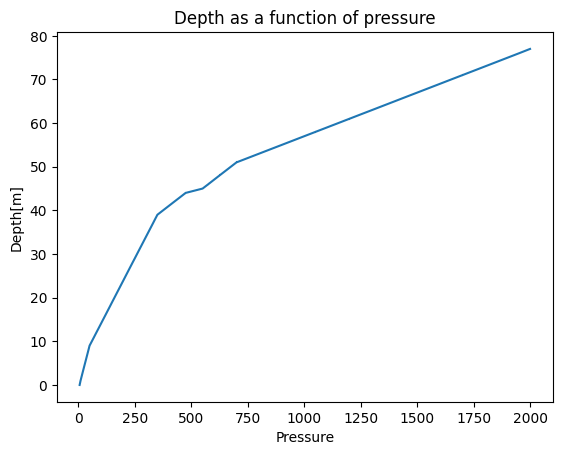

In [32]:
plt.errorbar(pmean, levels, xerr=Pstd)
plt.xlabel('Pressure')
plt.ylabel('Depth[m]')
plt.title('Depth as a function of pressure')

Text(0.5, 1.0, 'Depth as a function of density of water')

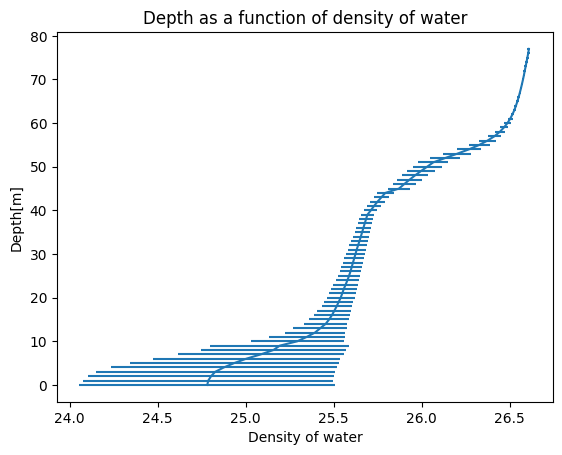

In [33]:
plt.errorbar(rdmean, levels, xerr=relative_density_std)
plt.xlabel('Density of water')
plt.ylabel('Depth[m]')
plt.title('Depth as a function of density of water')

**Q7) Account For Missing Data**

The profiles contain many missing values. These are indicated by the special “Not a Number” value, or `np.nan`.

When you take the mean or standard deviation of data with NaNs in it, the entire result becomes `NaN`. Instead, if you use the special functions `np.nanmean` and `np.nanstd`, you tell NumPy to ignore the NaNs.

Recalculate the means and standard deviations as in the previous sections using these functions and plot the results.

Hint: Links to the [`np.nanmean` documentation](https://numpy.org/doc/stable/reference/generated/numpy.nanmean.html) and the [`np.nanstd` documentation](https://numpy.org/doc/stable/reference/generated/numpy.nanstd.html).

Recalculate the means below ignoring the missing values. We trust that you can now come up with the full syntax yourself 😎

In [34]:
#i already did this in the last section so useless to do it now

Similarly, recalculate the standard deviations ignoring the missing values.

In [35]:
#i already did this in the last section so useless to do it now

**Q8) Create a scatter plot of the longitudinal (`lon`) and latitudinal (`lat`) coordinates of the ARGO floats.**

Again, we have not discussed it in the tutorial, but there is a really convenient scatter plot function called [`plt.scatter`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) provided by the Pyplot interface.

Bonus: Label your figure using `plt.xlabel`, `plt.ylabel`, and `plt.title`.

Bonus 2: Increase the fontsize of your labels by adding a `fontsize=` argument to the label functions.

Bonus 3: Make your scatter plot beautiful by changing the arguments of [`plt.scatter`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) listed in the documentation, for example `s=`.

Text(0.5, 1.0, 'Location of the ARGO floats')

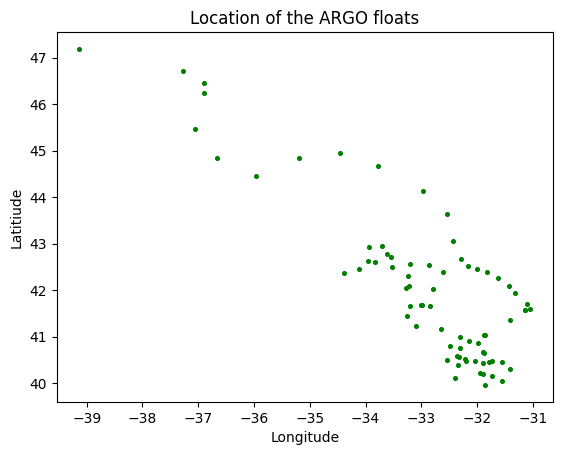

In [36]:
plt.scatter(lon,lat, c='g',s=7)
plt.xlabel('Longitude')
plt.ylabel('Latitiude')
plt.title('Location of the ARGO floats')# Fancy bonuses
